# 1. Configuration de imports

In [14]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sys.path.append(str(Path("..").resolve()))
from src.data.loader import compute_train_rul, load_cmapss_subset

sns.set_theme(style="whitegrid")

# Chargement
DATA_RAW = Path("../data/raw")
df_train, df_test, df_rul = load_cmapss_subset(DATA_RAW, subset="FD004")
df_train = compute_train_rul(df_train)

print(f"Jeu d'entraînement chargé : {df_train.shape}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Jeu d'entraînement chargé : (61249, 27)


# 2. Identifier et segmenter les 6 conditions de vol avec K-Means

In [15]:
settings_cols = ["setting_1", "setting_2", "setting_3"]

# Normalisation des settings pour le clustering
scaler_settings = StandardScaler()
settings_scaled = scaler_settings.fit_transform(df_train[settings_cols])

# K-Means avec 6 clusters 
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df_train["op_regime"] = kmeans.fit_predict(settings_scaled)

print("Distribution des points par régime de vol :")
display(df_train["op_regime"].value_counts().sort_index())


Distribution des points par régime de vol :


op_regime
0    15395
1     9224
2     9139
3     9091
4     9238
5     9162
Name: count, dtype: int64

# 3. Visualiser l'effet régime de vol vs usure

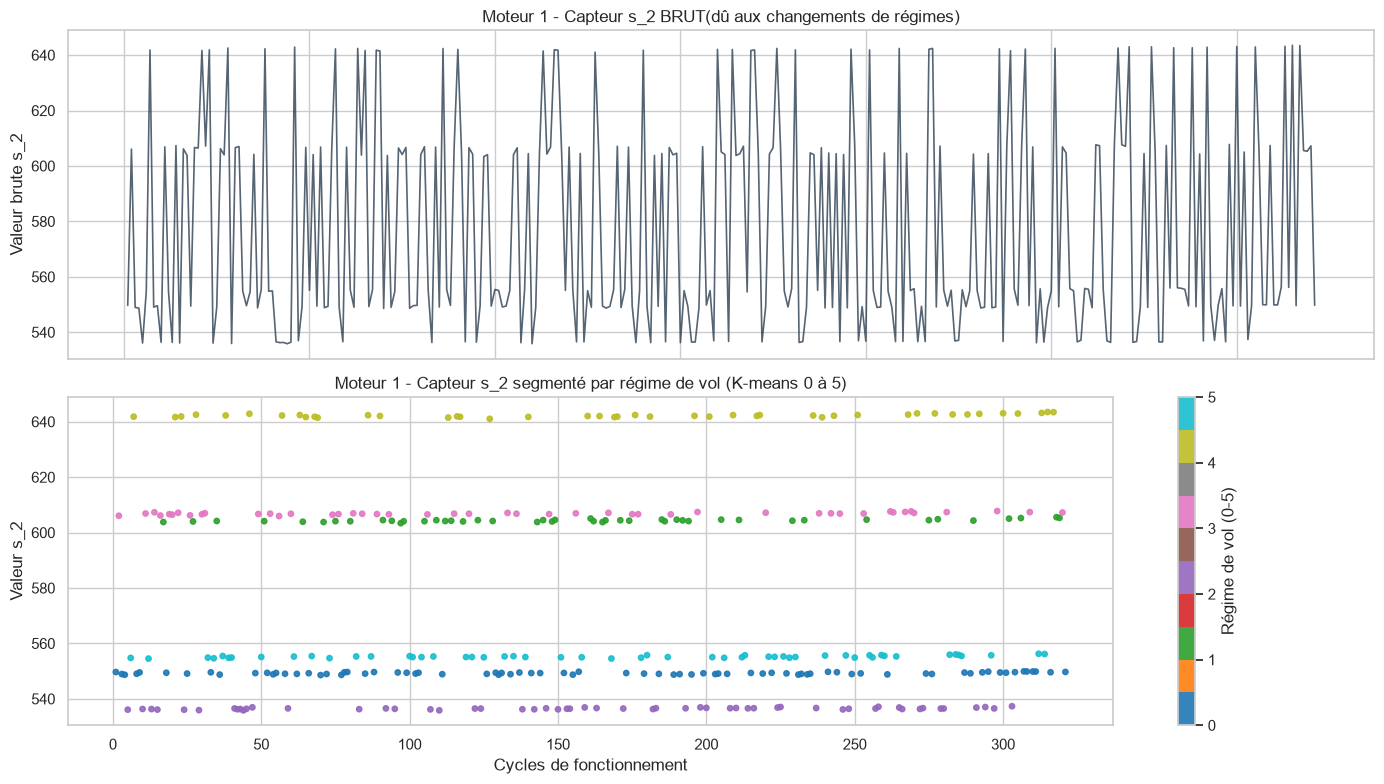

In [16]:
engine_1 = df_train[df_train["unit_id"] ==1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), sharex=True)

# 1. Vue brute : signal très bruité à cause des changements d'altitude/vitesse
ax1.plot(
    engine_1["time_cycles"],
    engine_1["s_2"],
    color="#2c3e50",
    lw=1.2,
    alpha=0.8

)
ax1.set_title("Moteur 1 - Capteur s_2 BRUT(dû aux changements de régimes)")
ax1.set_ylabel("Valeur brute s_2")

# 2. Vue colorée par régime opérationnel
scatter = ax2.scatter(
    engine_1["time_cycles"],
    engine_1["s_2"],
    c=engine_1["op_regime"],
    cmap="tab10",
    s=15,
    alpha=0.9
)
ax2.set_title("Moteur 1 - Capteur s_2 segmenté par régime de vol (K-means 0 à 5)")
ax2.set_xlabel("Cycles de fonctionnement")
ax2.set_ylabel("Valeur s_2")
fig.colorbar(scatter, ax=ax2, label="Régime de vol (0-5)")

plt.tight_layout()
plt.savefig(
    "../reports/figures/02_sensor_normalization.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# 4. Filtrage sur un seul régime de vol pour le moteur 1 

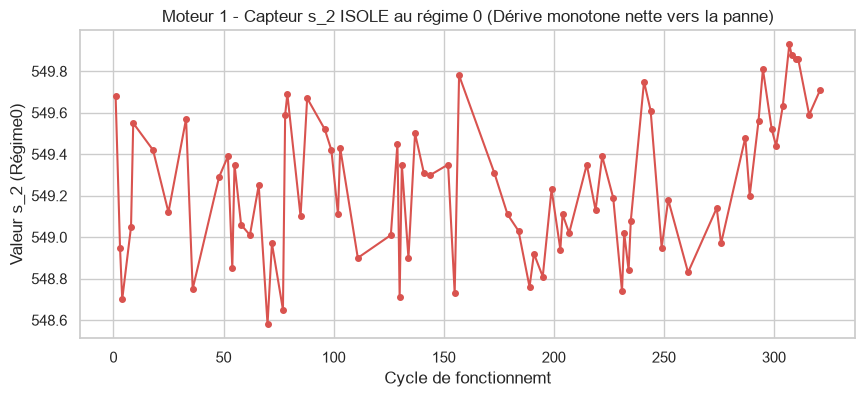

In [17]:
regime_0_m1 = engine_1[engine_1["op_regime"]==0]

plt.figure(figsize=(10, 4))
plt.plot(
    regime_0_m1["time_cycles"],
    regime_0_m1["s_2"],
    "o-",
    color="#d9534f",
    markersize=4
)
plt.title("Moteur 1 - Capteur s_2 ISOLE au régime 0 (Dérive monotone nette vers la panne)")
plt.xlabel("Cycle de fonctionnemt")
plt.ylabel("Valeur s_2 (Régime0)")
plt.show()

Si on isole un seul régime de vol (ex: régime 0), la tendance de dégradation monotone devient immédiatement visible

# 5. Corrélation des capteurs avec la cible RUL

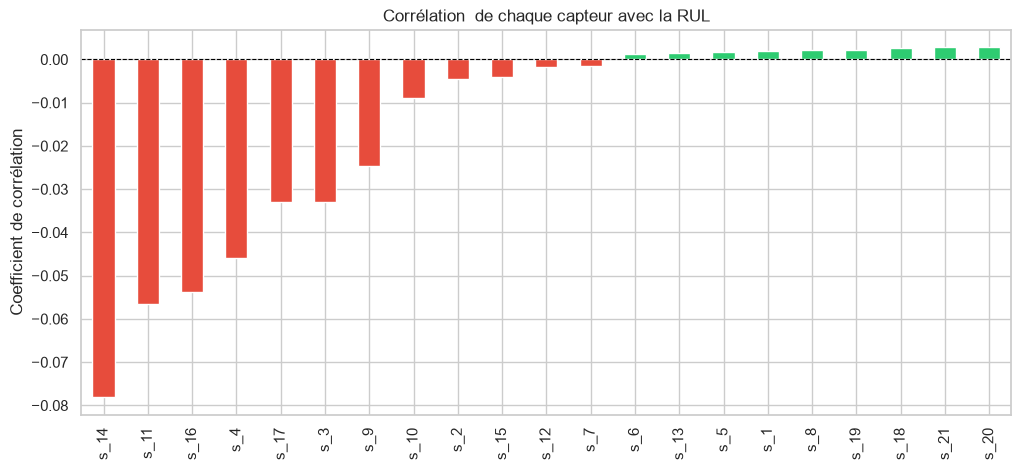

Top 5 capteurs les plus corrélés (positifs ou négatifs) :


s_14    0.078126
s_11    0.056639
s_16    0.053804
s_4     0.045881
s_17    0.032939
dtype: float64

In [18]:
sensor_cols = [col for col in df_train.columns if col.startswith("s_")]
correlations = (
    df_train[sensor_cols].apply(lambda x: x.corr(df_train["rul"])).sort_values()
)

plt.figure(figsize=(12, 5))
correlations.plot(
    kind="bar",
    color=np.where(correlations > 0, "#2ecc71", "#e74c3c")
)
plt.title("Corrélation  de chaque capteur avec la RUL")
plt.ylabel("Coefficient de corrélation")
plt.axhline(0, color="black", lw=0.8, linestyle="--")
plt.show()

print("Top 5 capteurs les plus corrélés (positifs ou négatifs) :")
display(correlations.abs().sort_values(ascending=False).head(5))